# Retina cell types comparison

## Setup

### Import libraries:

In [ ]:
## Set the right working directory:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())

import pandas as pd
import numpy as np
#import scipy as sc
import matplotlib.pyplot as plt
#from matplotlib.ticker import MultipleLocator
from matplotlib import gridspec
%matplotlib inline
from skimage import io
#from skimage import measure
#from skimage import color
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # avoid the "DOS decompression bomb warning/error" by unlimiting the size of the displayed image
from math import sin, cos, pi
# from math import floor
# from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
# from shapely.validation import explain_validity, make_valid
from read_roi import read_roi_zip, read_roi_file
#from scipy.stats import kde

from utils import *

/home/jovyan
/home/jovyan/projects/cellcount


### Define paths:

In [2]:
path2kdrive = "/home/jovyan/kDrive"
path2mainfolder = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea")
path2plots = os.path.join(path2mainfolder, "plots")
path2pickle = os.path.join(path2mainfolder, "pickled_data")
print(f"Plots will be saved in {path2plots}")

Plots will be saved in /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/plots


### Choose parameters (species, region, chunk):

In [3]:
species = 'Du26' #  'An01', 'Mc12', 'Aa14', 'Hr08', 'Hr21', 'Ft03', 'Mm04'
region = 'FT' # 'FT', 'NRc', 'NRtemporal', 'NR1-NR4'
# chunk = 'NR4' # for 'Hr21' and 'Aa14': 'NR1' to 'NR4' ; use None for all other cases
chunk = None

save_intermediary_data = False
save_final_data = False

### Sample-dependent options:

In [4]:
CELLTYPES = {
    'Aa14': {
        'NRc': ['cones', 'HC', 'BC', 'AC', 'GC'],
        'FT': ['cones', 'HC', 'BC', 'AC', 'GC'],
        'NR1-NR4': ['cones', 'HC', 'BC', 'AC', 'GC']
    },
    'An01': {
        'NRtemporal': ['cones', 'HC', 'BC', 'AC', 'GC']
    },
    'Du26': {
        'FT': ['cones', 'HC', 'BC', 'AC', 'GC']
    },    
    'Hr08': {
        'FT': ['cones', 'BC', 'AC', 'GC'],
        'FC': ['cones', 'HC', 'BC', 'AC', 'GC']
    },
    'Hr21': {
        'NR1-NR4': ['cones', 'HC', 'BC', 'AC', 'GC']
    },    
    'Mc12': {
        'NRtemporal': ['cones', 'HC', 'BC', 'AC', 'GC']
    },
    'Mm04': {
        'NRtemporal': ['cones', 'HC', 'BC', 'AC', 'GC']
    },
    'Ft03': {
        'FT': ['cones', 'HC', 'BC', 'AC', 'GC'],
    },
    'Sa09': {
        'NRtemporal': ['cones', 'BC', 'AC', 'GC'],
    }
}

CHUNKS = ['NR1', 'NR2', 'NR3', 'NR4']

celltypes_list = CELLTYPES[species][region]

colors = {
    'AC': '#BFBFBF',
    'BC': '#FDAF2F',
    'GC': '#93D050',
    'HC': '#595959',
    'cones': '#5BA7F3'
}

PATHS2IMAGE = {
    'Aa14': {
        'NRc': "Aa14_NRc_2b-1_2-63x-Stitching-04.czi - Aa14_NRc_2b-1_2-63x-Stitching-04.czi #1.tif",
        'FT': "Aa14_Ft_38-3_2-63x-Stitching-02.czi - Aa14_Ft_38-3_2-63x-Stitching-02.czi #1_original.tif",
        'NR1-NR4': {
            'NR1': "Aa14_NR1_3-1_2-63x-Stitching-04.czi - Aa14_NR1_3-1_2-63x-Stitching-04.czi #1.tif",
            'NR2': "Aa14_NR2_3-2_2-63x-Stitching-06.czi - Aa14_NR2_3-2_2-63x-Stitching-06.czi #1.tif",
            'NR3': "Aa14_NR3_2-3_2-63x-Stitching-02.czi - Aa14_NR3_2-3_2-63x-Stitching-02.czi #1.tif",
            'NR4': "Aa14_NR4_3-2_1-63x-Stitching-02.czi - Aa14_NR4_3-2_1-63x-Stitching-02.czi #1.tif",
        }
    },
    'An01': {
        'NRtemporal': "An01 - Fovea temporal 29_2 - 1 - overview-Stitching-05.tif"
    },
    'Du26': {
        'FT': "Du26_Ft_22_2-63x-Stitching-04.czi - Du26_Ft_22_2-63x-Stitching-04.czi #1.tif"
    },
    'Hr08': {
        'FT': "Hr08 - Fovea temp 23_1 - 1 - Rotated overview-Stitching-01.tif",
        'FC': "Hr08 - Fovea central 44_4 - 5 - fovea-Stitching-12.czi #1_clean_scale.tif"
    },
    'Hr21': {
        'NR1-NR4': {
            'NR1': "Hr21_NR1_2_3-1-40x_raw-Stitching-03.czi - Hr21_NR1_2_3-1-40x_raw-Stitching-03.czi #1.tif",
            'NR2': "Hr21_NR2_3_3-1-40x.czi - Hr21_NR2_3_3-1-40x.czi #1.tif",
            'NR3': "Hr21_NR3_2_3-1-40x-Stitching-02.czi - Hr21_NR3_2_3-1-40x-Stitching-02.czi #1.tif",
            'NR4': "Hr21_NR4_3_2-2-40x_raw-Stitching-06.czi - Hr21_NR4_3_2-2-40x_raw-Stitching-06.czi #1.tif"
        }
    },
    'Mc12': {
        'NRtemporal': "Mc12 - NRt 8_3 - 1 - 20x overview-Stitching-01_Darker_crop.tif"
    },
    'Mm04': {
        'NRtemporal': "Mm04 - Fovea temporal 26_4 - 2 - 40x fovea-Stitching-15.tif"
    },
    'Ft03': {
        'FT': "Ft03_Ft_42-3_1-63x-Stitching-04.czi - Ft03_Ft_42-3_1-63x-Stitching-04.czi #1.tif"
    },
    'Sa09': {
        'NRtemporal': "Sa09_NRt_20_2-63x-Stitching-05.czi - Sa09_NRt_20_2-63x-Stitching-05.czi #1.tif"
    }
}

paths2roiset = {
    'Aa14': {
        'NRc': {
            'AC': "Aa14_NRc_2b-1_2_AC_RoiSet.zip",
            'BC': "Aa14_NRc_2b-1_2_BC_RoiSet.zip",
            'GC': "Aa14_NRc_2b-1_2_GC_RoiSet.zip",
            'HC': "Aa14_NRc_2b-1_2_HC_RoiSet.zip",
            'cones': "Aa14_NRc_2b-1_2_cones_RoiSet.zip"
        },
        'FT': {
            'AC': "Aa14_FT_38_3_2_AC_RoiSet.zip",
            'BC': "Aa14_FT_38_3_2_BC_RoiSet.zip",
            'GC': "Aa14_FT_38_3_2_GC_RoiSet.zip",
            'HC': "Aa14_FT_38_3_2_HC_RoiSet.zip",
            'cones': "Aa14_FT_38_3_2_Cones_RoiSet.zip"
        },
        'NR1-NR4': {
            'NR1': {
                'AC': "Aa14_NR1_3_1_2_AC_RoiSet.zip",
                'BC': "Aa14_NR1_3_1_2_BC_RoiSet.zip",
                'GC': "Aa14_NR1_3_1_2_GC_RoiSet.zip",
                'HC': "Aa14_NR1_3_1_2_HC_RoiSet.zip",
                'cones': "Aa14_NR1_3_1_2_Cones_RoiSet.zip",
            },
            'NR2': {
                'AC': "Aa14_NR2_3_2_2_AC_RoiSet.zip",
                'BC': "Aa14_NR2_3_2_2_BC_RoiSet.zip",
                'GC': "Aa14_NR2_3_2_2_GC_RoiSet.zip",
                'HC': "Aa14_NR2_3_2_2_HC_RoiSet.zip",
                'cones': "Aa14_NR2_3_2_2_Cones_RoiSet.zip",
            },
            'NR3': {
                'AC': "Aa14_NR3_2_3_2_AC_RoiSet.zip",
                'BC': "Aa14_NR3_2_3_2_BC_RoiSet.zip",
                'GC': "Aa14_NR3_2_3_2_GC_RoiSet.zip",
                'HC': "Aa14_NR3_2_3_2_HC_RoiSet.zip",
                'cones': "Aa14_NR3_2_3_2_Cones_RoiSet.zip",
            },
            'NR4': {
                'AC': "Aa14_NR4_3_2_1_AC_RoiSet.zip",
                'BC': "Aa14_NR4_3_2_1_BC_RoiSet.zip",
                'GC': "Aa14_NR4_3_2_1_GC_RoiSet.zip",
                'HC': "Aa14_NR4_3_2_1_HC_RoiSet.zip",
                'cones': "Aa14_NR4_3_2_1_Cones_RoiSet.zip",
            },
        }
    },
    'An01': {
        'NRtemporal': {
            'AC': "An01_NRt_29_2_1_AC_RoiSet.zip",
            'BC': "An01_NRt_29_2_1_BC_RoiSet.zip",
            'GC': "An01_NRt_29_2_1_GC_RoiSet.zip",
            'HC': "An01_NRt_29_2_1_HC_RoiSet.zip",
            'cones': "An01_NRt_29_2_1_Cones_RoiSet.zip"
        },
    },
    'Du26': {
        'FT': {
            'AC': "Du26_Ft_22_2_AC_RoiSet.zip",
            'BC': "Du26_Ft_22_2_BC_RoiSet.zip",
            'GC': "Du26_Ft_22_2_GC_RoiSet.zip",
            'HC': "Du26_Ft_22_2_HC_RoiSet.zip",
            'cones': "Du26_Ft_22_2_Cones_RoiSet.zip"
        },
    },
    'Hr08': {
        'FT': {
            'AC': "Hr08_FT_23_1_1_AC_RoiSet.zip",
            'BC': "Hr08_FT_23_1_1_BC_RoiSet.zip",
            'GC': "Hr08_FT_23_1_1_GC_RoiSet.zip",
            'HC': None,
            'cones': "Hr08_FT_23_1_1_Cones_RoiSet.zip"
        },
        'FC': {
            'AC': "44_4_5_AC_RoiSet.zip",
            'BC': "44_4_5_BC_RoiSet.zip",
            'GC': "44_4_5_GC_RoiSet.zip",
            'HC': "44_4_5_HC_RoiSet.zip",
            'cones': "44_4_5_Cones_RoiSet.zip"
        },
    },
    'Hr21': {
        'NR1-NR4': {
            'NR1': {
                'AC': "Hr21_NR1_2_3_1_AC_RoiSet.zip",
                'BC': "Hr21_NR1_2_3_1_BC_RoiSet.zip",
                'GC': "Hr21_NR1_2_3_1_GC_RoiSet.zip",
                'HC': "Hr21_NR1_2_3_1_HC_RoiSet.zip",
                'cones': "Hr21_NR1_2_3_1_Cones_RoiSet.zip"
            },
            'NR2': {
                'AC': "Hr21_NR2_3_3_1_AC_RoiSet.zip",
                'BC': "Hr21_NR2_3_3_1_BC_RoiSet.zip",
                'GC': "Hr21_NR2_3_3_1_GC_RoiSet.zip",
                'HC': "Hr21_NR2_3_3_1_HC_RoiSet.zip",
                'cones': "Hr21_NR2_3_3_1_Cones_RoiSet.zip",
            },
            'NR3': {
                'AC': "Hr21_NR3_2_3_1_AC_RoiSet.zip",
                'BC': "Hr21_NR3_2_3_1_BC_RoiSet.zip",
                'GC': "Hr21_NR3_2_3_1_GC_RoiSet.zip",
                'HC': "Hr21_NR3_2_3_1_HC_RoiSet.zip",
                'cones': "Hr21_NR3_2_3_1_Cone_RoiSet.zip",
            },
            'NR4': {
                'AC': "Hr21_NR4_3_2_2_AC_RoiSet.zip",
                'BC': "Hr21_NR4_3_2_2_BC_RoiSet.zip",
                'GC': "Hr21_NR4_3_2_2_GC_RoiSet.zip",
                'HC': "Hr21_NR4_3_2_2_HC_RoiSet.zip",
                'cones': "Hr21_NR4_3_2_2_Cones_RoiSet.zip",
            }
        }
    },
    'Mc12': {
        'NRtemporal': {
            'AC': "Mc12_NRt_8_3_1_AC_RoiSet.zip",
            'BC': "Mc12_NRt_8_3_1_BC_RoiSet.zip",
            'GC': "Mc12_NRt_8_3_1_GC_RoiSet.zip",
            'HC': "Mc12_NRt_8_3_1_HC_RoiSet.zip",
            'cones': "Mc12_NRt_8_3_1_Cone_RoiSet.zip"
        },
    },
    'Mm04': {
        'NRtemporal': {
            'AC': "Mm04_NRt_26_4_2_AC_RoiSet.zip",
            'BC': "Mm04_NRt_26_4_2_BC_RoiSet.zip",
            'GC': "Mm04_NRt_26_4_2_GC_RoiSet.zip",
            'HC': "Mm04_NRt_26_4_2_HC_RoiSet.zip",
            'cones': "Mm04_NRt_26_4_2_Cone_RoiSet.zip"
        },
    },
    'Ft03': {
        'FT': {
            'AC': "Ft03_Ft_42_3_1_AC_RoiSet.zip",
            'BC': "Ft03_Ft_42_3_1_BC_RoiSet.zip",
            'GC': "Ft03_Ft_42_3_1_GC_RoiSet.zip",
            'HC': "Ft03_Ft_42_3_1_HC_RoiSet.zip",
            'cones': "Ft03_Ft_42_3_1_Cones_RoiSet.zip"
        },
    },
    'Sa09': {
        'NRtemporal': {
            'AC': "Sa09_NRt_20_2_AC_RoiSet.zip",
            'BC': "Sa09_NRt_20_2_BC_RoiSet.zip",
            'GC': "Sa09_NRt_20_2_GC_RoiSet.zip",
            'cones': "Sa09_NRt_20_2_Cone_RoiSet.zip"
        },
    },
}

# ratio microns/px :
IMG_RATIO = { 
    'Aa14': {
        'NRc': 0.1, # 10px par micron
        'FT': 0.1,
        'NR1-NR4': 0.1
    },
    'An01': {
        'NRtemporal': 1187/3807
    },
    'Du26': {
        'FT': 1592/16080
    },
    'Hr08': {
        'FT': 0.312,
        'FC': 368/3720
    },
    'Hr21': {
        'NR1-NR4': 0.1
    },
    'Mc12': {
        'NRtemporal': 2235/7164
    },
    'Mm04': {
        'NRtemporal': 456/2925
    },
    'Ft03': {
        'FT': 2687/27135
    },
    'Sa09': {
        'NRtemporal': 1746/17631
    },
}

# images widths in microns (used for defining xaxis limits) :
IMG_WIDTH = {
    'Aa14': {
        'NRc': 3753,
        'FT': 2679,
        'NR1-NR4': 1 ## dummy value, not used
    },
    'An01': {
        'NRtemporal': 1800 # 2063
    },
    'Du26': {
        'FT': 1600
    },
    'Hr08': {
        'FT': 1600,
        'FC': 400
    },
    'Hr21': {
        'NR1-NR4': 1 ## dummy value, not used
    },    
    'Mc12': {
        'NRtemporal': 2234 # old: 425
    },
    'Mm04': {
        'NRtemporal': 1017
    },
    'Ft03': {
        'FT': 2687
    },
    'Sa09': {
        'NRtemporal': 1679
    },
}

# should the coordinates of the centroids be unfold on the x-axis (relevant if the retina is much curved)
UNFOLD = {
    'Aa14': {
        'NRc': False,
        'FT': True,
        'NR1-NR4': {
            'NR1': False,
            'NR2': False,
            'NR3': False,
            'NR4': True
        }        
    },
    'An01': {
        'NRtemporal': True
    },
    'Du26': {
        'FT': False
    },
    'Hr08': {
        'FT': False,
        'FC': False
    },
    'Hr21': {
        'NR1-NR4': {
            'NR1': True,
            'NR2': False,
            'NR3': False,
            'NR4': False
        }
    },
    'Mc12': {
        'NRtemporal': False
    },
    'Mm04': {
        'NRtemporal': False
    },
    'Ft03': {
        'FT': False
    },
    'Sa09': {
        'NRtemporal': False
    },
}

UNFOLD_REFPOINT = {
    'Aa14': {
        'FT': 'max',
        'NR1-NR4': {
            'NR4': 'max'
        }
    },
    'An01': {
        'NRtemporal': 'max',
    },
    'Hr21': {
        'NR1-NR4': {
            'NR1': 'max'
        }
    },
}

X_AXIS_LIMITS = {
    'Aa14': {
        'NRc': [0, 1/IMG_RATIO[species][region] * IMG_WIDTH[species][region]],
        'FT': [0, 32500],
        'NR1-NR4': [0, 9.5e4],
    },
    'An01': {
        'NRtemporal': [100/IMG_RATIO[species][region], 1700/IMG_RATIO[species][region]],
    },
    'Du26': {
        'FT': [100/IMG_RATIO[species][region], 1700/IMG_RATIO[species][region]]
    },
    'Hr08': {
        'FT': [-350, 7000],
        'FC': [0, 1/IMG_RATIO[species][region] * IMG_WIDTH[species][region]]
    },
    'Hr21': {
        'NR1-NR4': [0, 9.5e4],
    },
    'Mc12': {
        'NRtemporal': [800/IMG_RATIO[species][region], 2400/IMG_RATIO[species][region]],
    },
    'Mm04': {
         # same x-limits than Ft03 FT
        'NRtemporal': [-0.675/IMG_RATIO[species][region] * IMG_WIDTH[species][region], 1.675/IMG_RATIO[species][region] * IMG_WIDTH[species][region] + 300],
    },
    'Ft03': {
        'FT': [400/IMG_RATIO[species][region], 1/IMG_RATIO[species][region] * IMG_WIDTH[species][region]],
    },
    'Sa09': {
        'NRtemporal': [400/IMG_RATIO[species][region], 1999/IMG_RATIO[species][region]],
    },
}

X_LABEL_STEP = {
    'Aa14': {
        'NRc': 250,
        'FT': 200,
        'NR1-NR4': 500,
    },
    'An01': {
        'NRtemporal': 200,
    },
    'Du26': {
        'FT': 200,
    },
    'Hr08': {
        'FT': 200,
        'FC': 50,
    },
    'Hr21': {
        'NR1-NR4': 500,
    },
    'Mc12': {
        'NRtemporal': 200,
    },
    'Mm04': {
        'NRtemporal': 200,
    },
    'Ft03': {
        'FT': 200,
    },
    'Sa09': {
        'NRtemporal': 200,
    },
}

Y_AXIS_LIMITS_HIST = {
    'Aa14': {
        'FT': (0, 150),
        'NRc': (0, 150),
        'NR1-NR4': (0, 500),
    },
    'An01': {
        'NRtemporal': (0, 140)
    },
    'Du26': {
        'FT': (0, 150)
    },
    'Hr08': {
        'FT': (0, 150),
        'FC': (0, 150)
    },
    'Hr21': {
        'NR1-NR4': (0, 500)
    },
    'Mc12': {
        'NRtemporal': (0, 140)
    },
    'Mm04': {
        'NRtemporal': (0, 200)
    },
    'Ft03': {
        'FT': (0, 200)
    },
    'Sa09': {
        'NRtemporal': (0, 140)
    },
}

Y_AXIS_LIMITS_BAR = {
    'Aa14': {
        'FT': (0, 500),
        'NRc': (0, 300),
        'NR1-NR4': (0, 300)
    },
    'An01': {
        'NRtemporal': (0, 300)
    },
    'Du26': {
        'FT': (0, 500)
    },
    'Hr08': {
        'FT': (0, 500),
        'FC': (0, 500)
    },
    'Hr21': {
        'NR1-NR4': (0, 300)
    },
    'Mc12': {
        'NRtemporal': (0, 300)
    },
    'Mm04': {
        'NRtemporal': (0, 500)
    },
    'Ft03': {
        'FT': (0, 500)
    },
    'Sa09': {
        'NRtemporal': (0, 300)
    },
}

SHOW_UNROLL_MATCH = {
    'Aa14': {
        'NRc': False,
        'FT': True,
        'NR1-NR4': False
    },
    'An01': {
        'NRtemporal': False
    },
    'Hr08': {
        'FT': False
    },
    'Hr21': {
        'NR1-NR4': False
    },
    'Sa09': {
        'NRtemporal': False
    },
}

FIGSIZE = {
    'Aa14': {
        'NRc': (20, 9),
        'FT': (15, 6),
        'NR1-NR4': (20, 10)
    },
    'An01': {
        'NRtemporal': (15, 6),
    },
    'Du26': {
        'FT': (15, 10)
    },
    'Hr08': {
        'FT': (15, 6),
        'FC': (10, 14)
    },
    'Hr21': {
        'NR1-NR4': (20, 10)
    },
    'Mc12': {
        'NRtemporal': (15, 6),
    },
    'Mm04': {
        'NRtemporal': (15, 6),
    },
    'Ft03': {
        'FT': (15, 6),
    },
    'Sa09': {
        'NRtemporal': (15, 6),
    },
}

HISTSETTINGS = {
    'Aa14': {
        'NRc': {'bins_width': 50, 'room4legend': 2000},
        'FT': {'bins_width': 50, 'room4legend': 0},
        'NR1-NR4': {'bins_width': 100, 'room4legend': 0},
    },
    'An01': {
        'NRtemporal': {'bins_width': 50, 'room4legend': 0},
    },
    'Du26': {
        'FT': {'bins_width': 50, 'room4legend': 1000},
    },
    'Hr08': {
        'FT': {'bins_width': 50, 'room4legend': 800},
        'FC': {'bins_width': 25, 'room4legend': 400},
    },
    'Hr21': {
        'NR1-NR4': {'bins_width': 100, 'room4legend': 1000},
    },
    'Mc12': {
        'NRtemporal': {'bins_width': 50, 'room4legend': 0},
    },
    'Mm04': {
        'NRtemporal': {'bins_width': 50, 'room4legend': 0},
    },
    'Ft03': {
        'FT': {'bins_width': 50, 'room4legend': 1500},
    },
    'Sa09': {
        'NRtemporal': {'bins_width': 50, 'room4legend': 0},
    },
}

GRIDSPEC = {
    'Aa14': {
        'NRc': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.4, 0.25, 0.2, 0.15]},
        'FT': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]},
        'NR1-NR4': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [1.4, 1]},
    },
    'An01': {
        'NRtemporal': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]},
    },
    'Du26': {
        'FT': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.4, 0.25, 0.2, 0.15]},
    },
    'Hr08': {
        'FT': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]},
        'FC': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.65, 0.15, 0.1, 0.1]},
    },
    'Hr21': {
        'NR1-NR4': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [1.4, 1]},
    },
    'Mc12': {
        'NRtemporal': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]}
    },
    'Mm04': {
        'NRtemporal': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]}
    },
    'Ft03': {
        'FT': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]}
    },
    'Sa09': {
        'NRtemporal': {'hspace': 0.15, 'wspace': 0, 'height_ratios': [0.5, 0.4, 0.3]},
    },
}

# same accross all species:
FIGPARAMS = {
    'labelsize': 10,
    'fontsize': 12,
    'legendfontsize': 10,
    'legendtitlesize': 12,
}

### Settings used for region NR1-NR4 only:
SHIFT_CENTROIDS = {
    'Hr21': {
        'NR1-NR4':{
            'NR1': 0,
            'NR2': 1.8e4,
            'NR3': 1.8e4 + 2.4e4,
            'NR4': 1.8e4 + 2.4e4 + 2.5e4
        }
    },
    'Aa14': {
        'NR1-NR4':{# sample-dependent paths:
            'NR1': 0,
            'NR2': 2.2e4,
            'NR3': 2.2e4 + 2.5e4,
            'NR4': 2.2e4 + 2.5e4 + 2.4e4
        }
    }
}

# Discard centroids in bad zones:
DISCARD_RANGE = {
    'Hr21': [(16000, 20000), (39000, 45000), (53000, 56000), (65000, 69000), (89000, 91000)],
    'Aa14': [(18000, 24000), (45000, 48000), (67000, 71000)]
}

### Sample-dependent paths:

In [5]:
if region == 'NR1-NR4':
    path2folder = os.path.join(path2mainfolder, species + '_' + region, chunk)
    path2image = os.path.join(path2folder, PATHS2IMAGE[species][region][chunk])
else:
    path2folder = os.path.join(path2mainfolder, species + '_' + region)
    path2image = os.path.join(path2folder, PATHS2IMAGE[species][region])

## Import and prepare data

### Load and optionally rotate image:

In [6]:
im = io.imread(path2image)
im_dim = im.shape
print(im_dim)

(4128, 16080)


(4128, 16080)


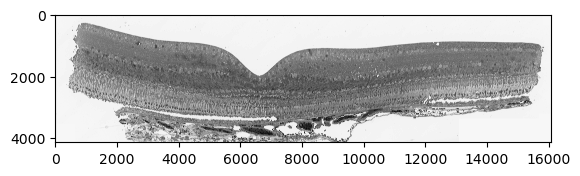

In [7]:
if species == 'Aa14' and region == 'FT': # rotate pi/2 clockwise
    im_arr_rotated = np.rot90(im, k=3, axes=(0, 1))
elif species == 'Aa14' and region == 'NR1-NR4' and chunk == 'NR2':
    im_arr_rotated = np.rot90(im, k=2, axes=(0, 1)) # rotate pi clockwise
elif species == 'Aa14' and region == 'NR1-NR4' and chunk == 'NR4':
    im_arr_rotated = np.flip(im, axis=0) # flip wrt to Ox
    im_arr_rotated = np.rot90(im_arr_rotated, k=3, axes=(0, 1)) # rotate pi/2 clockwise
elif species == 'An01' and region == 'NRtemporal':
    im_arr_rotated = np.rot90(im, k=3, axes=(0, 1)) # rotate pi/2 clockwise
elif species == 'Mc12' and region == 'NRtemporal': 
    im_arr_rotated = np.rot90(im, k=2, axes=(0, 1)) # rotate pi clockwise
    im_arr_rotated = im_arr_rotated[0:1750,:] # crop
elif species == 'Hr21' and region == 'NR1-NR4' and chunk in ['NR2', 'NR4']:
    im_arr_rotated = np.flip(im, axis=1) # flip wrt to Oy
elif species == 'Du26' and region == 'FT':
    im_arr_rotated = np.flip(im, axis=1) # flip wrt to Oy
elif species == 'Mm04':
    im_arr_rotated = np.rot90(im, k=1, axes=(0, 1))
elif species == 'Sa09' and region == 'NRtemporal':
    im_arr_rotated = np.rot90(im, k=3, axes=(0, 1)) # rotate pi/2 clockwise
else:
    im_arr_rotated = im
print(im_arr_rotated.shape)
plt.imshow(im_arr_rotated, cmap=plt.cm.gray)

In [8]:
## Rotate rois if image must be rotated
def make_rotation(X, Y, species, region, chunk=None):
    if species == 'Hr08' and region == 'FT': # rotate 3*pi/4 and flip
        angle=141.5 * pi/180
        X_rot = cos(angle)*X + sin(angle)*Y
        Y_rot = -sin(angle)*X + cos(angle)*Y
        x_shift = 2470
        y_shift = 7130
        coords = np.column_stack((-X_rot + x_shift, Y_rot + y_shift))

    elif species == 'Aa14' and region == 'FT': # rotate -pi/2
        x_shift = 27054
        y_shift = 0
        coords = np.column_stack((-Y + x_shift, X + y_shift))

    elif species == 'An01' and region == 'NRtemporal': # rotate -pi/2
        x_shift = 6620
        y_shift = 0
        coords = np.column_stack((-Y + x_shift, X + y_shift))

    elif species == 'Aa14' and region == 'NR1-NR4' and chunk == 'NR2':
        angle = -pi
        X_rot = cos(angle)*X + sin(angle)*Y
        Y_rot = -sin(angle)*X + cos(angle)*Y
        x_shift = 24768
        y_shift = 4320
        coords = np.column_stack((X_rot + x_shift, Y_rot + y_shift))

    elif species == 'Aa14' and region == 'NR1-NR4' and chunk == 'NR4':
        angle = pi/2
        X_rot = cos(angle)*X + sin(angle)*Y
        Y_rot = -sin(angle)*X + cos(angle)*Y
        x_shift = 0
        y_shift = 0
        coords = np.column_stack((X_rot + x_shift, -Y_rot + y_shift))

    elif species == 'Mc12' and region == 'NRtemporal':
        angle = -pi
        X_rot = cos(angle)*X + sin(angle)*Y
        Y_rot = -sin(angle)*X + cos(angle)*Y
        x_shift = 7160
        y_shift = 2310
        coords = np.column_stack((X_rot + x_shift, Y_rot + y_shift))

    elif species == 'Hr21' and region == 'NR1-NR4' and chunk == 'NR2':
        x_shift = 22392
        y_shift = 0
        coords = np.column_stack((-X + x_shift, Y + y_shift)) # flip according to Oy
    
    elif species == 'Hr21' and region == 'NR1-NR4' and chunk == 'NR4':
        x_shift = 26928
        y_shift = 0
        coords = np.column_stack((-X + x_shift, Y + y_shift)) # flip according to Oy
    
    elif species == 'Du26' and region == 'FT':
        x_shift = 16080
        y_shift = 0
        coords = np.column_stack((-X + x_shift, Y + y_shift)) # flip according to Oy

    elif species == 'Mm04':
        angle=90 * pi/180
        X_rot = cos(angle)*X + sin(angle)*Y
        Y_rot = -sin(angle)*X + cos(angle)*Y
        x_shift = 0
        y_shift = 2920
        coords = np.column_stack((X_rot + x_shift, Y_rot + y_shift))
    
    elif species == 'Sa09' and region == 'NRtemporal': # rotate -pi/2
        x_shift = 16980
        y_shift = 0
        coords = np.column_stack((-Y + x_shift, X + y_shift))
    
    else: # no rotation
        coords = np.column_stack((X, Y))
    
    return coords

### TESTING: Import rois from a given cell type and check-out the polygons from imported roiset:

In [9]:
celltype = 'cones'
if region == 'NR1-NR4':
    path2roiset = os.path.join(path2folder, paths2roiset[species][region][chunk][celltype])
else:
    path2roiset = os.path.join(path2folder, paths2roiset[species][region][celltype])
print(path2roiset)

/home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_Cones_RoiSet.zip


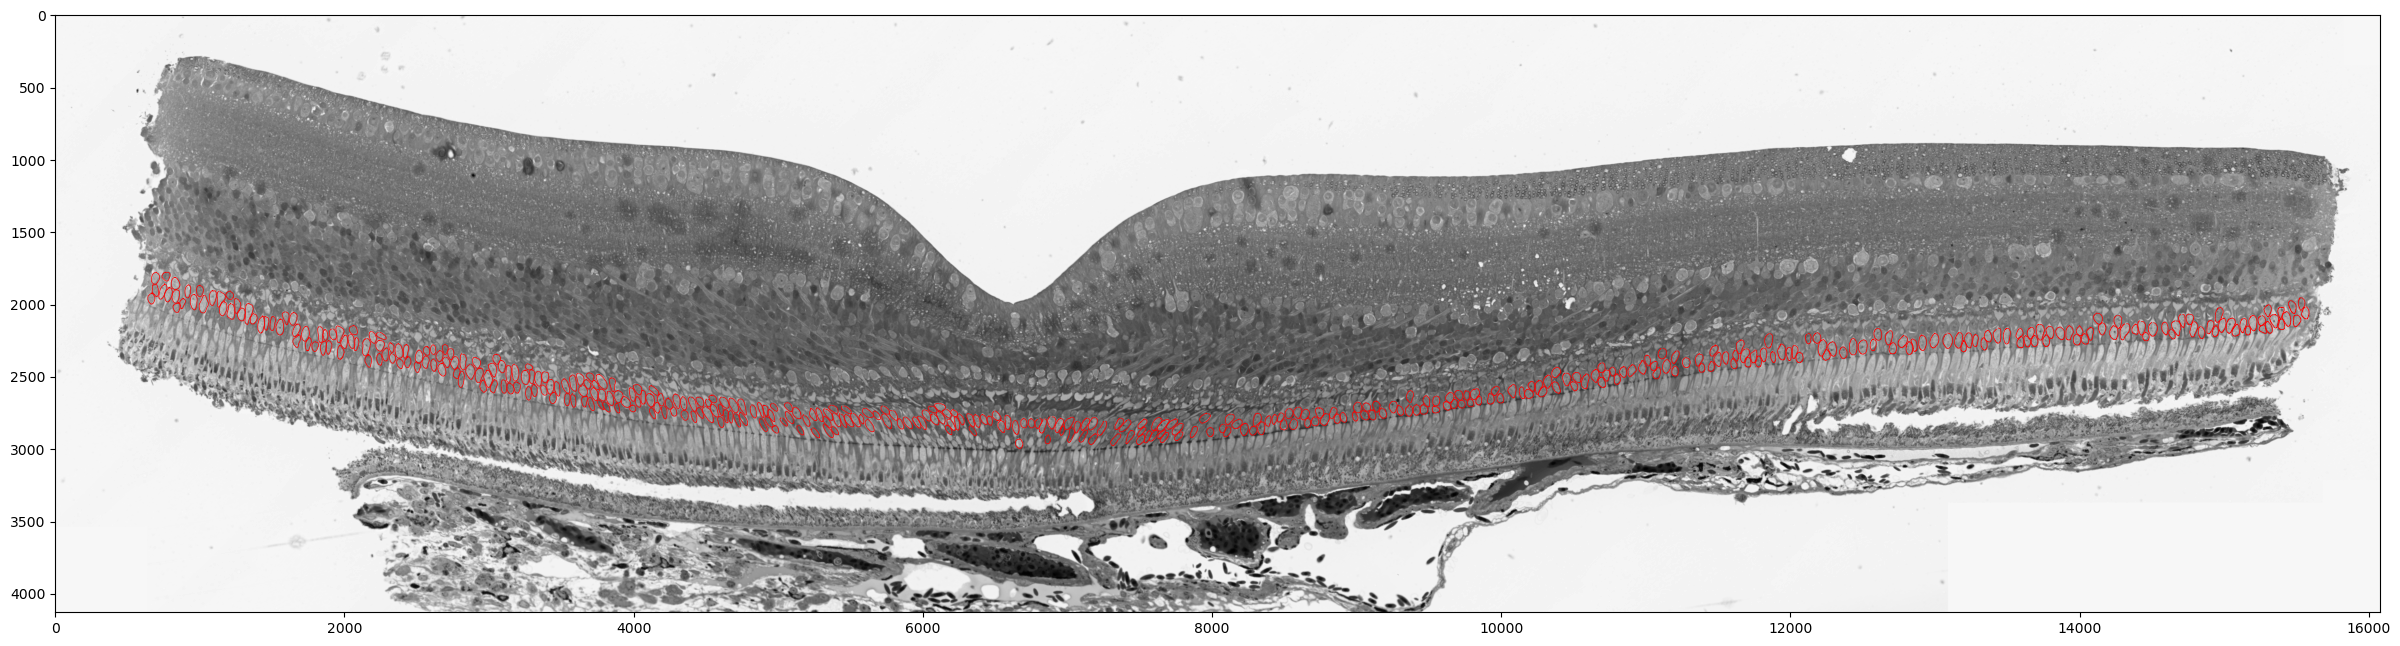

In [10]:
rois = read_roi_zip(path2roiset)
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(30, 20))
fig, ax1 = plt.subplots(1, 1, figsize=(30, 10))
ax1.imshow(im_arr_rotated, cmap=plt.cm.gray)
polygon_list = []
for r in rois:
    if rois[r]['type'] == 'line':
        pass
    else:
        coords = make_rotation(np.array(rois[r]['x']), np.array(rois[r]['y']), species, region, chunk)
        polygon_list.append((r, contour2polygon(coords)))
        ax1.plot(coords[:,0], coords[:,1], linewidth=0.5, color='red')
    

### Unfolding curved sections:

In [11]:
def unroll_set(X, Y, ref_point='min'):

    # get the index of the lowest/highest y coordinate:
    if ref_point == 'min':
        i_ref = Y.index(min(Y))
        ref_type = 'Lowest'
    elif ref_point == 'max':
        i_ref = Y.index(max(Y))
        ref_type = 'Highest'

    print(f"{ref_type} y coordinate index = {i_ref}")

    # compute the length of segments of the rectified curve:
    Deltas = []
    for i in range(len(X)-1):
        Dx = X[i+1] - X[i]
        Dy = Y[i+1] - Y[i]
        Dl = (Dx**2 + Dy**2)**0.5
        Deltas.append(Dl - Dx)

    # shift the x coordinate of each point accordingly:
    X_hat = []
    shift_list = []
    for i in range(len(X)):
        if i < i_ref:
            shift = -sum(Deltas[i:i_ref])
            #x_hat = X[i] - sum(Deltas[i:i_ref])
        elif i > i_ref:
            shift = sum(Deltas[i_ref:i])
            #x_hat = X[i] + sum(Deltas[i_ref:i])
        else:
            shift = 0
            #x_hat = X[i]

        shift_list.append(shift)
        x_hat = X[i] + shift
        X_hat.append(x_hat)

    return shift_list, X_hat


def closest(L, k):
    return min(range(len(L)), key = lambda i: abs(L[i]-k))


def unroll(S, X, shift_list):
    S_hat = []
    for i in range(len(S)):
        i_closest = closest(X, S[i])
        dx_closest = S[i] - X[i_closest]
        if dx_closest == 0:
            s_hat = S[i] + shift_list[i_closest]
        else:
            if dx_closest > 0:
                i_next_closest = i_closest + 1
            else:
                i_next_closest = i_closest - 1
            
            dx_closest = abs(dx_closest)
            dx_next_closest = abs(S[i] - X[i_next_closest])
            n = dx_closest + dx_next_closest
            shift = (n-dx_closest)/n * shift_list[i_closest] + dx_closest/n * shift_list[i_next_closest]
            s_hat = S[i] + shift
        
        S_hat.append(s_hat)
        
    return S_hat


def unroll_reference_curve(species, region, chunk, ref_point, path2folder, celltype=None):
    print(path2folder)
    print(f"{species}_{region}_curvature_line_PointSet_{celltype}")
    if celltype is not None:
        curve_shape_filename = f"{species}_{region}_curvature_line_PointSet_{celltype}"
    else:
        curve_shape_filename = f"{species}_{region}_curvature_line_PointSet"
        
    print(os.path.join(path2folder, curve_shape_filename + '.roi'))
    curve_points = read_roi_file(os.path.join(path2folder, curve_shape_filename + '.roi'))
    curve_shape_coords = make_rotation(
        np.array(curve_points[curve_shape_filename]['x']),
        np.array(curve_points[curve_shape_filename]['y']),
        species,
        region,
        chunk
    )        
    X = list(reversed(list(curve_shape_coords[:,0])))
    Y = list(reversed(list(curve_shape_coords[:,1])))
    
    shift_list, X_hat = unroll_set(X,Y, ref_point=ref_point)

    return shift_list, X, Y, X_hat
    

#### Test the unrolling on a sample of cells:

In [12]:
if region == 'NR1-NR4':
    should_unfold = UNFOLD[species][region][chunk]
    if should_unfold:
        ref_point = UNFOLD_REFPOINT[species][region][chunk]
else: 
    should_unfold = UNFOLD[species][region]
    if should_unfold:
        ref_point = UNFOLD_REFPOINT[species][region]

if should_unfold:
    shift_list, X, Y, X_hat = unroll_reference_curve(species, region, chunk, ref_point, path2folder, celltype)

else:
    print('No unrolling for this sample')
    X = None,
    Y = None

No unrolling for this sample


In [13]:
if X is not None and Y is not None:
    # get centroids (in pixel coordinates) of each polygon, and its x-coordinate:
    centroids = [polygon_list[i][1].centroid for i in range(len(polygon_list))]
    centroids_x = [i.coords[0][0] for i in centroids]
    centroids_y = [i.coords[0][1] for i in centroids]
    nb_rois = len(centroids_x)
    # remove possible duplicates:
    centroids_x = list(dict.fromkeys(centroids_x))
    centroids_y = list(dict.fromkeys(centroids_y))
    nb_cells = len(centroids_x)
    print('Number of removed duplicates :', nb_rois - nb_cells)

    S_hat = unroll(centroids_x, X, shift_list)

    sample_step = 50
    centroids_x_sample = [centroids_x[i] for i in range(len(centroids_x)) if i % sample_step == 0] + centroids_x[-1:]
    centroids_y_sample = [centroids_y[i] for i in range(len(centroids_y)) if i % sample_step == 0] + centroids_y[-1:]
    S_hat_sample = [S_hat[i] for i in range(len(S_hat)) if i % sample_step == 0] + S_hat[-1:]

    plt.scatter(X, Y, zorder=3, marker='.', color='blue')
    plt.scatter(X_hat, [0]*len(X_hat), color='red', marker='.', zorder=3)
    plt.scatter(centroids_x_sample, centroids_y_sample, zorder=3, color='cyan', marker='.')
    plt.scatter(S_hat_sample, [0]*len(S_hat_sample), color='magenta', marker='.', zorder=3)
    for i in range(len(centroids_x_sample)): 
        plt.plot([centroids_x_sample[i], S_hat_sample[i]], [centroids_y_sample[i], 0], color='black', linewidth=0.5)
    plt.gca().set_aspect('equal')
    plt.grid()
    plt.title('Projecting a sample of centroids to the x-axis')

In [14]:
if X is not None and Y is not None:
    fig, ax1 = plt.subplots(1, 1, figsize=(15, 5))
    ax1.imshow(im_arr_rotated, cmap=plt.cm.gray)
    ax1.scatter(X, Y, zorder=3, marker='.', color='blue')
    ax1.scatter(X_hat, [0] * len(X_hat), color='red', marker='.', zorder=3)
    ax1.scatter(centroids_x_sample, centroids_y_sample, zorder=3, color='cyan', marker='.')
    ax1.scatter(S_hat_sample, [0] * len(S_hat_sample), color='magenta', marker='.', zorder=3)
    for i in range(len(centroids_x_sample)): 
        ax1.plot([centroids_x_sample[i], S_hat_sample[i]], [centroids_y_sample[i], 0], color='black', linewidth=0.5)
    ax1.set_aspect('equal')
    #ax1.set_ylim(1.8e4, -500)
    ax1.grid()
    ax1.set_title('Projecting a sample of the cells centroids onto the x-axis')

### Import rois from all given cell types:

In [15]:
def import_all_rois(species, region, chunk=None):

    _path2mainfolder = path2mainfolder
    _paths2roiset = paths2roiset
    _celltypes_list = celltypes_list
    
    centroids_x_alltypes = []
    for ct in _celltypes_list:
        if region == 'NR1-NR4':
            path2folder = os.path.join(_path2mainfolder, species + '_' + region, chunk)
            path2roiset = os.path.join(path2folder, _paths2roiset[species][region][chunk][ct])
        else:
            path2folder = os.path.join(_path2mainfolder, species + '_' + region)
            path2roiset = os.path.join(path2folder, _paths2roiset[species][region][ct])
        print(ct, path2roiset)
        rois = read_roi_zip(path2roiset)
        # convert rois to shapely.Polygon objects:
        polygon_list = []
        for r in rois:
            if rois[r]['type'] == 'line':
                pass
            else:
                coords = make_rotation(np.array(rois[r]['x']), np.array(rois[r]['y']), species, region, chunk)
                polygon_list.append((r, contour2polygon(coords)))
            
        # get centroids (in pixel coordinates) of each polygon, and its x-coordinate:
        centroids = [polygon_list[i][1].centroid for i in range(len(polygon_list))]
        centroids_x = [i.coords[0][0] for i in centroids]
        nb_rois = len(centroids_x)
        # remove possible duplicates:
        centroids_x = list(dict.fromkeys(centroids_x))
        nb_cells = len(centroids_x)
        print(f"Number of {ct} cells: {nb_cells}")
        print('Number of removed duplicates :', nb_rois - nb_cells)

        if region == 'NR1-NR4':
            should_unfold = UNFOLD[species][region][chunk]
            if should_unfold:
                print(f"species {species}, region {region} and chunk {chunk} : unfolding sample")
                ref_point = UNFOLD_REFPOINT[species][region][chunk]
        else: 
            should_unfold = UNFOLD[species][region]
            if should_unfold:
                print(f"species {species}, region {region} : unfolding sample")
                ref_point = UNFOLD_REFPOINT[species][region]

        if should_unfold:
            shift_list, X, _, _ = unroll_reference_curve(species, region, chunk, ref_point, path2folder, ct)
            S_hat = unroll(centroids_x, X, shift_list)
            centroids_x_alltypes.append(S_hat)
        else:
            centroids_x_alltypes.append(centroids_x)
    
        if ct == 'GC':
            print('For ganglion cells, computing the area of each cell...')
            # for ganglion cells, get the areas (in pixel coordinates) of each polygon, and its x-coordinate:
            gc_areas = [polygon_list[i][1].area * IMG_RATIO[species][region]**2 for i in range(len(polygon_list))]
            if chunk is None:
                if UNFOLD[species][region]:
                    df_gc_areas = pd.DataFrame({'x': centroids_x, 'x_unfold': S_hat, 'gc_area': gc_areas})
                else:
                    df_gc_areas = pd.DataFrame({'x': centroids_x, 'gc_area': gc_areas})
            else:
                if UNFOLD[species][region][chunk]:
                    df_gc_areas = pd.DataFrame({'x': centroids_x, 'x_unfold': S_hat, 'gc_area': gc_areas})
                else:
                    df_gc_areas = pd.DataFrame({'x': centroids_x, 'gc_area': gc_areas})

    df_gc_areas['diameters'] = df_gc_areas['gc_area'].apply(diameter_from_area)
    return centroids_x_alltypes, df_gc_areas

In [16]:
if region == 'NR1-NR4':
    centroids_x_alltypes_bychunk = {}
    df_gc_areas_bychunk = {}
    for ch in CHUNKS:
        print(ch)
        centroids_x_alltypes_bychunk[ch], df_gc_areas_bychunk[ch] = import_all_rois(species, region, ch)

    # concatenate all chunks (lists) by cell type:
    centroids_x_alltypes = []
    for ct in range(len(celltypes_list)):
        centroids_x_giventype = []
        for chunk in CHUNKS:
            shift_centroids = SHIFT_CENTROIDS[species][region][chunk]
            for c in centroids_x_alltypes_bychunk[chunk][ct]:
                centroids_x_giventype.append(c + shift_centroids)
        centroids_x_alltypes.append(centroids_x_giventype)

    # concatenate all chunks for cell area (dataframes):.gc_area
    # df_gc_areas = pd.concat([df_gc_areas_bychunk[ch] for ch in CHUNKS])
    gc_area_max = np.max(pd.concat([df_gc_areas_bychunk[ch] for ch in CHUNKS]).gc_area)
else:
    centroids_x_alltypes, df_gc_areas = import_all_rois(species, region)
    gc_area_max = np.max(df_gc_areas.gc_area)
    

cones /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_Cones_RoiSet.zip
Number of cones cells: 424
Number of removed duplicates : 0
HC /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_HC_RoiSet.zip
Number of HC cells: 90
Number of removed duplicates : 0
BC /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_BC_RoiSet.zip
Number of BC cells: 1233
Number of removed duplicates : 0
AC /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_AC_RoiSet.zip
Number of AC cells: 287
Number of removed duplicates : 0
GC /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/Du26_FT/Du26_Ft_22_2_GC_RoiSet.zip
Number of GC cells: 261
Number of removed duplicates : 0
For ganglion cells, computing the area of each cell...


In [17]:
if region == 'NR1-NR4':
    df_gc_areas = pd.concat(df_gc_areas_bychunk, ignore_index=True)
    df_gc_areas.sort_values('gc_area', ascending=False, inplace=True)
else:
    df_gc_areas.sort_values('x', ascending=True, inplace=True)

df_gc_areas

,x,gc_area,diameters
257,848.941511,15.501839,4.442697
256,907.185663,14.060948,4.231188
255,917.255108,19.108970,4.932575
254,971.737579,17.393623,4.705980
253,1050.982032,29.185411,6.095902
...,...,...,...
4,14519.279940,31.483976,6.331401
3,14591.160150,25.318528,5.677724
2,14699.479609,61.649585,8.859723
1,14894.236249,49.539233,7.941997


In [18]:
if save_intermediary_data:
    # Saved data for further use:
    pickle_filename = f"GC_{species}_{region}.pickle"
    df_gc_areas.to_pickle(os.path.join(path2pickle, pickle_filename))

## Plot data

For each species and region, plot:

0) optionally, the original histology image
1) a histogram with cell counts for all types of cells,
2) a bar plot with the areas of the GC
3) a line plot gshowing the HC/Cone ratio

/tmp/ipykernel_3824/1020363957.py:172: RuntimeWarning: invalid value encountered in divide
  ratio_GC_cones = h_GC / h_cones


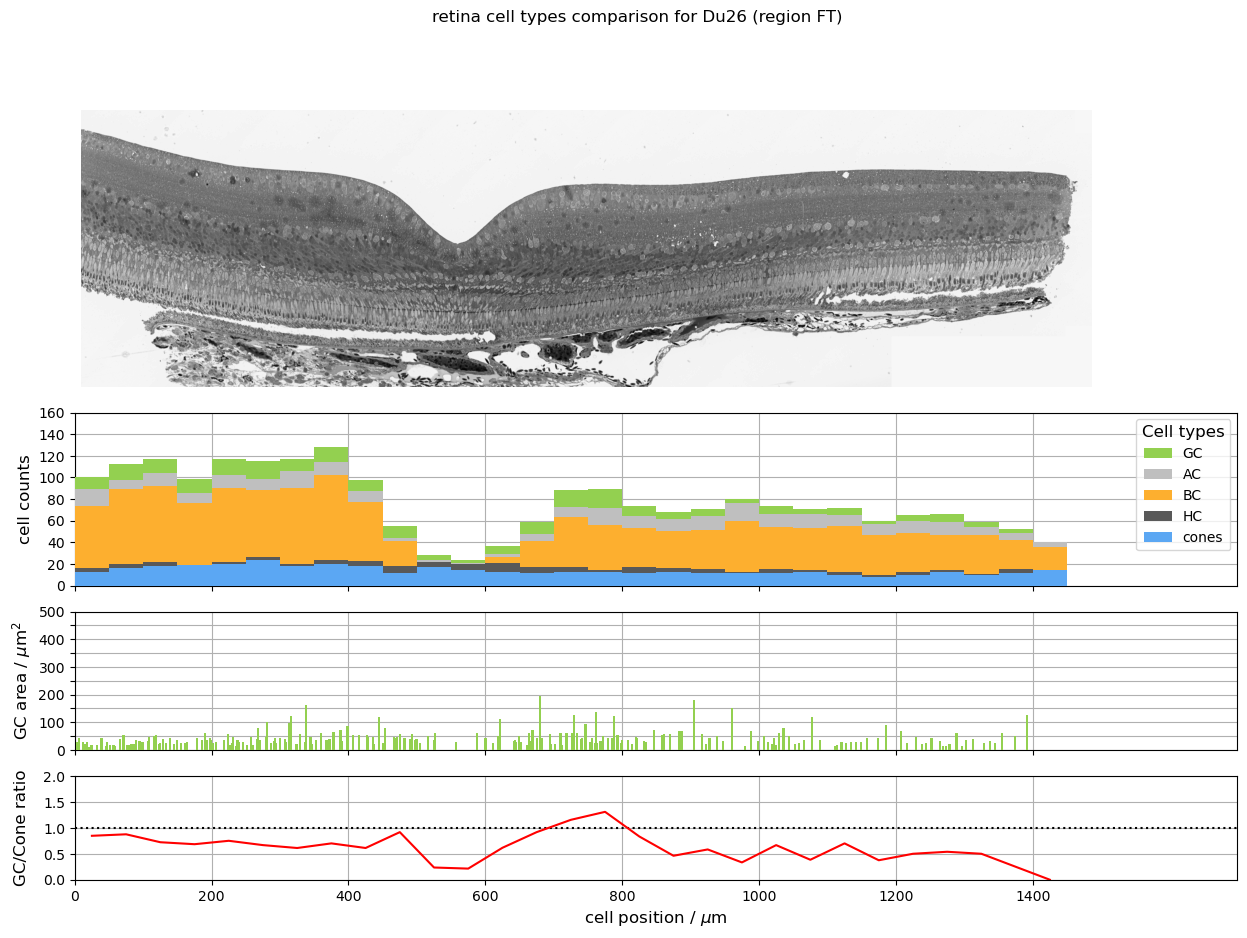

In [19]:
room_for_legend = HISTSETTINGS[species][region]['room4legend'] # additional space (in px) at the end of the x-axis to insert the legend
# create figure:
fig = plt.figure(figsize=FIGSIZE[species][region])
# create a grid for subplots:
gs_dict = GRIDSPEC[species][region]
img_ratio = IMG_RATIO[species][region]

if (species in ['Du26'] and region == 'FT') or (species == 'Aa14' and region == 'NRc') or (species == 'Hr08' and region == 'FC'): # figures with histology image
    subplots_nb = 4
elif region == 'NR1-NR4':
    subplots_nb = 2
else: # plot ratios GC/cones
    subplots_nb = 3

spec = gridspec.GridSpec(ncols=1, nrows=subplots_nb, hspace=gs_dict['hspace'], wspace=gs_dict['wspace'], height_ratios=gs_dict['height_ratios'])
### define x-axis limits, ticks and labels:
x_axis_limits = X_AXIS_LIMITS[species][region] # in pixels
label_step = X_LABEL_STEP[species][region] # in microns
x_ticks = np.arange(x_axis_limits[0], x_axis_limits[1], label_step*1/img_ratio) # ticks locations are in pixels
x_labels = [t*label_step for t in range(len(x_ticks))] # ticks labels are in microns
x_labels_empty = [' ' for t in range(len(x_ticks))]

#### plot histology image:
if subplots_nb == 4: 
    ax = fig.add_subplot(spec[0])
    ax.imshow(im_arr_rotated, cmap=plt.cm.gray, aspect='equal')

    if UNFOLD[species][region] and SHOW_UNROLL_MATCH[species][region]:
        ax.scatter(centroids_x_sample, centroids_y_sample, zorder=3, color='cyan', marker='.')
        ax.scatter(S_hat_sample, [im_arr_rotated.shape[0] + 600] * len(S_hat_sample), color='magenta', marker='.', zorder=3)
        for i in range(len(centroids_x_sample)): 
            ax.plot([centroids_x_sample[i], S_hat_sample[i]], [centroids_y_sample[i], im_arr_rotated.shape[0] + 500], color='black', linewidth=0.5)

    ax.set_xlim(x_axis_limits[0], x_axis_limits[1] + room_for_legend)
    ax.set_yticks(ticks=[])
    ax.axis('off')
    ax.set_frame_on(False)
    # change the fontsize:
    # ax.tick_params(axis='x', labelsize=FIGPARAMS['labelsize'])
    # ax.tick_params(axis='y', labelsize=FIGPARAMS['labelsize'])


#### plot histogram:
if subplots_nb == 4:
    ax = fig.add_subplot(spec[1])
else:
    ax = fig.add_subplot(spec[0])

bins_width = HISTSETTINGS[species][region]['bins_width'] # set here bins width in microns
bins_number = round((img_ratio * x_axis_limits[1] - img_ratio * x_axis_limits[0]) / bins_width)
bins_edges = np.arange(x_axis_limits[0], x_axis_limits[1], bins_width / img_ratio)
h, bins, _ = ax.hist(centroids_x_alltypes,
                    #bins_number,
                    bins_edges,
                    range=(x_axis_limits[0], x_axis_limits[1]),
                    stacked=True,
                    density=False,
                    label=celltypes_list,
                    color=[colors[t] for t in celltypes_list],
                    zorder=3
                    )

handles, labels = ax.get_legend_handles_labels()
# reverse order of the colors in legend:
ax.legend(handles[::-1], labels[::-1],
        title='Cell types',
        loc='upper right',
        prop={"size": FIGPARAMS['legendfontsize']})

# change the fontsize
ax.tick_params(axis='x', labelsize=FIGPARAMS['labelsize'])
ax.tick_params(axis='y', labelsize=FIGPARAMS['labelsize'])
ax.get_legend().get_title().set_fontsize(FIGPARAMS['legendtitlesize']) # title of legend

ax.set_xlim(x_axis_limits[0], x_axis_limits[1] + room_for_legend)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels_empty)

ax.set_ylim(ymin=Y_AXIS_LIMITS_HIST[species][region][0], ymax=Y_AXIS_LIMITS_HIST[species][region][1])
if region == 'NR1-NR4':
    y_ticks = np.arange(0, Y_AXIS_LIMITS_HIST[species][region][1] + 50, 50)
else:
    y_ticks = np.arange(0, Y_AXIS_LIMITS_HIST[species][region][1] + 20, 20)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks)
ax.set_ylabel('cell counts', fontsize=FIGPARAMS['fontsize'])

ax.grid()

if region == 'NR1-NR4':
    ## Shade area in both plots that should be discarded:
    for gap in range(len(DISCARD_RANGE[species])):
        x_discard_min = DISCARD_RANGE[species][gap][0]
        x_discard_max = DISCARD_RANGE[species][gap][1]
        ax.axvspan(x_discard_min, x_discard_max, alpha=0.5, color='#C0C0C0', linestyle='--', linewidth=1, fill=True, hatch ='/', zorder=4)


##### Plot with GC areas:
if subplots_nb == 4:
    ax = fig.add_subplot(spec[2])
else:
    ax = fig.add_subplot(spec[1])

ax.set_xlim(x_axis_limits[0], x_axis_limits[1] + room_for_legend)
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels_empty)
if subplots_nb == 2:
    ax.set_xticklabels([int(x) for x in x_labels])
    ax.set_xlabel('cell position / $\mu$m', fontsize=FIGPARAMS['fontsize'])

ax.set_ylim(ymin=Y_AXIS_LIMITS_BAR[species][region][0], ymax=Y_AXIS_LIMITS_BAR[species][region][1])
y_ticks = np.arange(0, Y_AXIS_LIMITS_BAR[species][region][1] + 50, 50)
ax.set_yticks(y_ticks)
ax.set_yticklabels([t if t % 100 == 0 else '' for t in y_ticks])
ax.set_ylabel('GC area / $\mu$m$^2$', fontsize=FIGPARAMS['fontsize'])
ax.grid()

if region == 'NR1-NR4':
    for chunk in CHUNKS:
        shift_centroids = SHIFT_CENTROIDS[species][region][chunk]
        df_chunk_plot = df_gc_areas_bychunk[chunk]
        df_chunk_plot.sort_values('x', inplace=True)
        if UNFOLD[species][region][chunk]:
            gc_x_list = list(df_chunk_plot['x_unfold'])
        else:
            gc_x_list = list(df_chunk_plot['x'])
            
        ax.bar([c + shift_centroids for c in gc_x_list], df_gc_areas_bychunk[chunk]['gc_area'], width=60, color='#93D050', zorder=3)

    ## Shade area in both plots that should be discarded:
    for gap in range(len(DISCARD_RANGE[species])):
        x_discard_min = DISCARD_RANGE[species][gap][0]
        x_discard_max = DISCARD_RANGE[species][gap][1]
        ax.axvspan(x_discard_min, x_discard_max, alpha=0.5, color='#C0C0C0', linestyle='--', linewidth=1, fill=True, hatch ='/', zorder=4)
        
else:
    bar_width = (X_AXIS_LIMITS[species][region][1]-X_AXIS_LIMITS[species][region][0]) * 2e-3
    if UNFOLD[species][region]:
        ax.bar(df_gc_areas['x_unfold'], df_gc_areas['gc_area'], width=bar_width, color='#93D050', zorder=3)
    else:
        ax.bar(df_gc_areas['x'], df_gc_areas['gc_area'], width=bar_width, color='#93D050', zorder=3)

# change the fontsize:
ax.tick_params(axis='x', labelsize=FIGPARAMS['labelsize'])
ax.tick_params(axis='y', labelsize=FIGPARAMS['labelsize'])


#### plot with ratio GC/cones:
if subplots_nb == 4: # with histology image
    ax = fig.add_subplot(spec[3])
elif subplots_nb == 3:
    ax = fig.add_subplot(spec[2])

if subplots_nb >= 3:
    ax.set_xlim(x_axis_limits[0], x_axis_limits[1] + room_for_legend)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([int(x) for x in x_labels])
    ax.set_xlabel('cell position / $\mu$m', fontsize=FIGPARAMS['fontsize'])
    if species in ['Aa14'] and region in ['FT']:
        ax.set_ylim(0, 6)
        ax.set_yticks(np.arange(0, 7, 1))
        ylabel_padding = 20
    else:
        ax.set_ylim(0, 2)
        ax.set_yticks([0, 0.5, 1, 1.5, 2])
        ylabel_padding = 10

    ax.hlines(1, x_axis_limits[0], x_axis_limits[1] + room_for_legend, color='black', linestyle='dotted')
    ax.set_ylabel('GC/Cone ratio', fontsize=FIGPARAMS['fontsize'], labelpad=ylabel_padding)
    h_GC = h[-1] - h[-2]
    h_cones = h[0]
    ratio_GC_cones = h_GC / h_cones
    bins_centers = [0.5*(bins[i]+bins[i+1]) for i in range(len(bins)-1)]
    plt.plot(bins_centers, ratio_GC_cones, color='red')
    ax.grid()


plt.rcParams['savefig.dpi'] = 600
fig.suptitle(f"retina cell types comparison for {species} (region {region})")

if save_final_data:
    fig.savefig(os.path.join(path2plots, f"cell_types_distribution_{species}_{region}.png"), facecolor='white')